In [3]:
%load_ext autoreload
%autoreload 2


from paper_utils import *



In [12]:
runs = {'7v9829hs': 'bioasq-Llama-2-70b-chat-squad-deberta',
 'p612l1sb': 'bioasq-Llama-2-70b-squad-deberta',
 'l73gru9d': 'bioasq-Llama-2-7b-chat-squad-deberta',
 '1qxx1kdc': 'squad-Llama-2-7b-chat-squad-deberta',
 'lpiqolkq': 'trivia_qa-Llama-2-7b-chat-squad-deberta',
 'c49kowku': 'trivia_qa-Llama-2-70b-squad-deberta',
 '2y5iz0yp': 'bioasq-Llama-2-7b-squad-deberta',
 'qulmpm7j': 'trivia_qa-Llama-2-70b-chat-squad-deberta',
 't8wh24jt': 'squad-Mistral-7B-v0.1-squad-deberta',
 'gw7whx93': 'squad-Llama-2-70b-chat-squad-deberta',
 'm2c7th22': 'svamp-Mistral-7B-Instruct-v0.1-squad-deberta',
 'olwzg5bi': 'svamp-falcon-40b-instruct-squad-deberta',
 'acpjfjji': 'nq-Llama-2-13b-squad-deberta',
 '0r03r4ax': 'svamp-Llama-2-70b-chat-8bit-squad-deberta',
 'azwidv4c': 'squad-Llama-2-70b-squad-deberta',
 'fkihims9': 'squad-falcon-40b-squad-deberta',
 'wyzh61ot': 'nq-falcon-40b-squad-deberta',
 'kpkiwbpq': 'squad-falcon-7b-squad-deberta',
 '05e0el64': 'nq-Llama-2-7b-8bit-squad-deberta',
 'fhfig18t': 'nq-falcon-7b-squad-deberta',
 'wpw9v1u4': 'bioasq-Mistral-7B-Instruct-v0.1-squad-deberta',
 'smn3kdcl': 'nq-Llama-2-70b-8bit-squad-deberta',
 'popney4v': 'squad-falcon-7b-instruct-squad-deberta',
 'ivow64r4': 'trivia_qa-falcon-40b-instruct-squad-deberta',
 'kian8scl': 'trivia_qa-falcon-7b-squad-deberta',
 'h1qzfoib': 'svamp-Llama-2-7b-chat-8bit-squad-deberta',
 '4fcnvsqb': 'bioasq-Mistral-7B-v0.1-squad-deberta',
 'g8xqqzni': 'trivia_qa-Mistral-7B-Instruct-v0.1-squad-deberta',
 'wzf7odwp': 'nq-Mistral-7B-v0.1-squad-deberta',
 '27c51395': 'trivia_qa-falcon-7b-instruct-squad-deberta',
 'r14kcdbf': 'nq-Llama-2-7b-chat-8bit-squad-deberta',
 '0vuyld41': 'trivia_qa-falcon-40b-squad-deberta',
 '0pezm02t': 'squad-Mistral-7B-Instruct-v0.1-squad-deberta',
 'pg044kfn': 'nq-falcon-40b-instruct-squad-deberta',
 'jhryxlsp': 'svamp-falcon-7b-squad-deberta',
 'm7ih9fim': 'svamp-falcon-7b-instruct-squad-deberta',
 'suuj8oxo': 'svamp-Llama-2-7b-8bit-squad-deberta',
 'qmhhwrjv': 'bioasq-falcon-40b-instruct-squad-deberta',
 '47jzvyes': 'nq-Llama-2-70b-chat-8bit-squad-deberta',
 'm0yjhoi5': 'bioasq-falcon-7b-squad-deberta',
 '8fznysu6': 'nq-falcon-7b-instruct-squad-deberta',
 '3izqbmbi': 'trivia_qa-Llama-2-7b-squad-deberta',
 '7frk2qf0': 'bioasq-falcon-40b-squad-deberta',
 'l3y8uaz9': 'svamp-Mistral-7B-v0.1-squad-deberta',
 'wvvywjrf': 'bioasq-falcon-7b-instruct-squad-deberta',
 'aknee3xw': 'nq-Mistral-7B-Instruct-v0.1-squad-deberta',
 'n82au3mi': 'squad-Llama-2-13b-squad-deberta',
 'jtlocie6': 'svamp-Llama-2-13b-chat-squad-deberta',
 'f66n5ih1': 'svamp-Llama-2-70b-8bit-squad-deberta',
 'uccuhe0p': 'bioasq-Llama-2-13b-chat-squad-deberta',
 'kwbvh1mv': 'squad-Llama-2-13b-chat-squad-deberta',
 'jcy1gycy': 'trivia_qa-Mistral-7B-v0.1-squad-deberta',
 'y0kjtvok': 'svamp-Llama-2-13b-squad-deberta',
 'usvfhxcw': 'svamp-falcon-40b-squad-deberta',
 '2s1j50vf': 'squad-falcon-40b-instruct-squad-deberta',
 'mtjgy334': 'squad-Llama-2-7b-squad-deberta',
 'ps7l7b7u': 'trivia_qa-Llama-2-13b-squad-deberta',
 'z5a0l59g': 'nq-Llama-2-13b-chat-squad-deberta',
 's0y2hef2': 'bioasq-Llama-2-13b-squad-deberta',
 'y9zo86ge': 'trivia_qa-Llama-2-13b-chat-squad-deberta'}

runs = {k: v[:-len('-squad-deberta')] for k, v in runs.items()}


In [13]:
columns = ['wandbid', 'c.dataset', 'c.model_name']
rows = []
for name, row in runs.items():
    rows.append([name, row.split('-')[0], '-'.join(row.split('-')[1:])])


arg_df = pd.DataFrame(rows, columns=columns)
arg_df['c.model_name'] = arg_df['c.model_name'].map(lambda x: x if not x.endswith('-8bit') else x[:-len('-8bit')])
arg_df

,wandbid,c.dataset,c.model_name
0,7v9829hs,bioasq,Llama-2-70b-chat
1,p612l1sb,bioasq,Llama-2-70b
2,l73gru9d,bioasq,Llama-2-7b-chat
3,1qxx1kdc,squad,Llama-2-7b-chat
4,lpiqolkq,trivia_qa,Llama-2-7b-chat
5,c49kowku,trivia_qa,Llama-2-70b
6,2y5iz0yp,bioasq,Llama-2-7b
7,qulmpm7j,trivia_qa,Llama-2-70b-chat
8,t8wh24jt,squad,Mistral-7B-v0.1
9,gw7whx93,squad,Llama-2-70b-chat


In [14]:
# all_results = {}
for wandb_id in runs:
    if wandb_id not in all_results:
        all_results[wandb_id], _ = restore_file(wandb_id)

In [15]:
arg_df.pivot(index='c.model_name', columns='c.dataset', values='wandbid')

c.dataset,bioasq,nq,squad,svamp,trivia_qa
c.model_name,,,,,
Llama-2-13b,s0y2hef2,acpjfjji,n82au3mi,y0kjtvok,ps7l7b7u
Llama-2-13b-chat,uccuhe0p,z5a0l59g,kwbvh1mv,jtlocie6,y9zo86ge
Llama-2-70b,p612l1sb,smn3kdcl,azwidv4c,f66n5ih1,c49kowku
Llama-2-70b-chat,7v9829hs,47jzvyes,gw7whx93,0r03r4ax,qulmpm7j
Llama-2-7b,2y5iz0yp,05e0el64,mtjgy334,suuj8oxo,3izqbmbi
Llama-2-7b-chat,l73gru9d,r14kcdbf,1qxx1kdc,h1qzfoib,lpiqolkq
Mistral-7B-Instruct-v0.1,wpw9v1u4,aknee3xw,0pezm02t,m2c7th22,g8xqqzni
Mistral-7B-v0.1,4fcnvsqb,wzf7odwp,t8wh24jt,l3y8uaz9,jcy1gycy
falcon-40b,7frk2qf0,wyzh61ot,fkihims9,usvfhxcw,0vuyld41


model,bioasq,nq,squad,svamp,trivia_qa
dataset,,,,,
Llama-2-13b,0.4900,0.4400,0.3175,0.486667,0.6850
Llama-2-13b-chat,0.4600,0.4650,0.2600,0.450000,0.6525
Llama-2-70b,0.5425,NaN,0.4000,NaN,0.7850
Llama-2-70b-8bit,NaN,0.5700,NaN,0.656667,NaN
Llama-2-70b-chat,0.5225,NaN,0.3225,NaN,0.7475
Llama-2-70b-chat-8bit,NaN,0.4675,NaN,0.596667,NaN
Llama-2-7b,0.4475,NaN,0.2700,NaN,0.6375
Llama-2-7b-8bit,NaN,0.3925,NaN,0.413333,NaN
Llama-2-7b-chat,0.4500,NaN,0.2450,NaN,0.6125


Text(0, 0.5, 'accuracy')

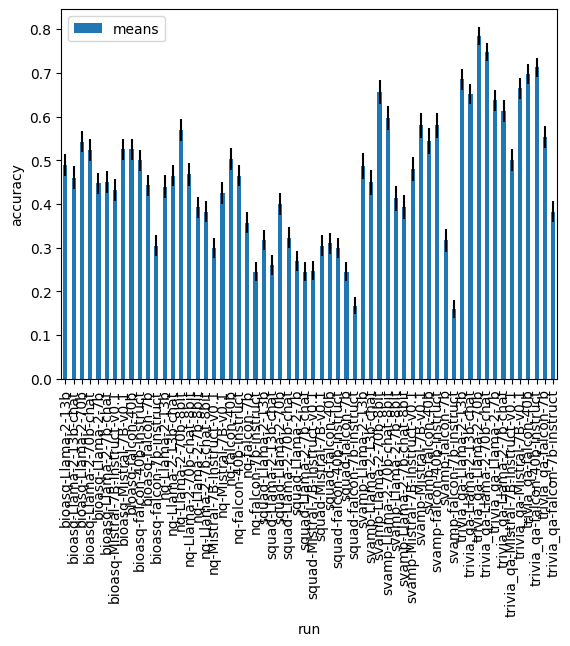

In [16]:
def get_perf_df(runs, all_results=all_results):
    perfdf = {}
    for wandb_id, run_name in runs.items():
        results = all_results[wandb_id]    
        perfdf[wandb_id] = get_perfs(results)
    
    runids = list(perfdf.keys())
    tmp = pd.DataFrame(perfdf[runids[0]])
    tmp['wandbid'] = runids[0]
    tmp['run'] = runs[runids[0]]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(perfdf[runid])
        tmp2['wandbid'] = runid
        tmp2['run'] = runs[runid]
        
        tmp = pd.concat([tmp, tmp2])
    
    perfdf = tmp.reset_index()
    
    tmp = perfdf.set_index('method').loc['accuracy']
    tmp['model'] = tmp.run.map(lambda x: '-'.join(x.split('-')[:1]))
    tmp['dataset'] = tmp.run.map(lambda x: '-'.join(x.split('-')[1:]))
    display(tmp.pivot(columns='model', index='dataset', values='means'))

    pdfs = {}
    for wandb_id in runs:
        results = all_results[wandb_id]
        pdfs[wandb_id] = get_uncertainty_df(results)
    
    runids = list(pdfs.keys())

    tmp = pd.DataFrame(pdfs[runids[0]])
    tmp['run'] = runs[runids[0]]
    tmp['wandbid'] = runids[0]
    
    for runid in runids[1:]:
        tmp2 = pd.DataFrame(pdfs[runid])
        tmp2['run'] = runs[runid]
        tmp2['wandbid'] = runid
    
        tmp = pd.concat([tmp, tmp2])
    
    all_runs = tmp.reset_index()

    return perfdf, pdfs, all_runs

perfdf, pdfs, all_runs = get_perf_df(runs)

perfdf = perfdf.merge(arg_df, on='wandbid')
all_runs = all_runs.merge(arg_df, on='wandbid')

plot_bar(perfdf.set_index('method').loc['accuracy'].set_index('run').sort_index())
plt.gca().set_ylabel('accuracy')

In [18]:
# load pik OOD runs

pik_runs = {'jf5mfwkz': 'Llama-2-70b-nq-squad',
 'oypdffl9': 'Llama-2-70b-svamp-trivia_qa',
 'yeo8gc3l': 'Llama-2-70b-chat-trivia_qa-svamp',
 'b0j1gyan': 'falcon-7b-instruct-svamp-nq',
 '5gdqt75x': 'Llama-2-70b-chat-squad-trivia_qa',
 '1reyoj48': 'Llama-2-70b-chat-svamp-bioasq',
 'roff79kp': 'Llama-2-70b-chat-svamp-trivia_qa',
 'knbvoixa': 'Llama-2-70b-chat-nq-trivia_qa',
 'ahwi4qce': 'Llama-2-13b-chat-squad-trivia_qa',
 '69yqpwvw': 'Llama-2-70b-bioasq-svamp',
 'yf46od88': 'Llama-2-70b-bioasq-squad',
 '8bcn1ybb': 'Llama-2-70b-chat-svamp-nq',
 '0p9wzdru': 'Llama-2-7b-chat-squad-bioasq',
 '4x00tbhr': 'Llama-2-70b-bioasq-nq',
 'yqlq7bmt': 'Llama-2-7b-bioasq-svamp',
 'mrylukvv': 'Llama-2-70b-nq-bioasq',
 '9ucpokq9': 'Mistral-7B-Instruct-v0.1-trivia_qa-bioasq',
 'jbwyqs3x': 'Llama-2-7b-bioasq-trivia_qa',
 '11a0atlr': 'Mistral-7B-Instruct-v0.1-svamp-bioasq',
 'eq8artri': 'Llama-2-13b-chat-squad-bioasq',
 'vmp9j9cw': 'Llama-2-70b-squad-trivia_qa',
 'nxa5wpex': 'Mistral-7B-v0.1-nq-bioasq',
 't1zima2o': 'Llama-2-70b-trivia_qa-bioasq',
 'gvavygde': 'falcon-40b-instruct-bioasq-nq',
 'tvli8t5r': 'Llama-2-70b-svamp-squad',
 'wgww81eo': 'Llama-2-70b-bioasq-trivia_qa',
 '68xjeoho': 'Llama-2-70b-chat-squad-svamp',
 '0x7nx4ic': 'Llama-2-70b-nq-svamp',
 'gs9krcdv': 'Llama-2-7b-nq-bioasq',
 'k1rhhfos': 'Mistral-7B-v0.1-trivia_qa-bioasq',
 '2bikca3v': 'Llama-2-70b-chat-nq-svamp',
 '9dx2xh5t': 'Llama-2-7b-chat-nq-trivia_qa',
 'qz9soy33': 'Llama-2-7b-bioasq-nq',
 'y09yvnwt': 'Llama-2-70b-chat-bioasq-svamp',
 'jnmnzuy1': 'Llama-2-7b-nq-svamp',
 'cg4fbhag': 'Llama-2-7b-nq-squad',
 'unksin9j': 'Llama-2-70b-chat-bioasq-squad',
 'dlxyoin7': 'Llama-2-7b-chat-squad-nq',
 's69z98uh': 'falcon-40b-instruct-bioasq-squad',
 '7s1zs2lu': 'Llama-2-7b-bioasq-squad',
 'cf2urell': 'Mistral-7B-v0.1-bioasq-squad',
 'ohvyl2k9': 'Llama-2-70b-squad-bioasq',
 'kh0srd85': 'falcon-40b-instruct-nq-squad',
 'rn5yv2ok': 'Llama-2-70b-chat-trivia_qa-nq',
 'tvoc5s59': 'Llama-2-7b-squad-bioasq',
 '79r6rpt9': 'Llama-2-70b-squad-nq',
 'ko767eub': 'Mistral-7B-v0.1-trivia_qa-squad',
 'gnb37mu0': 'Llama-2-7b-chat-squad-trivia_qa',
 'e1luuoer': 'Llama-2-7b-chat-svamp-bioasq',
 '7gczy4dg': 'Llama-2-70b-chat-nq-bioasq',
 '8v49hiif': 'Mistral-7B-v0.1-squad-bioasq',
 'fm15nawc': 'Mistral-7B-Instruct-v0.1-svamp-nq',
 '6sow2k1q': 'Llama-2-7b-chat-squad-svamp',
 '80l6fdux': 'Llama-2-70b-trivia_qa-nq',
 'hoj3qwyr': 'Mistral-7B-v0.1-bioasq-svamp',
 '7sr9ycc5': 'falcon-40b-instruct-nq-trivia_qa',
 'whg3d27k': 'Llama-2-70b-chat-squad-nq',
 '2d69w5gr': 'Llama-2-70b-chat-bioasq-trivia_qa',
 'fxgf7eeu': 'Llama-2-7b-squad-nq',
 'jaaykm57': 'Mistral-7B-v0.1-trivia_qa-nq',
 '3p47c1uc': 'Llama-2-70b-chat-nq-squad',
 'nynzuujh': 'falcon-40b-instruct-nq-bioasq',
 'c5b2brnm': 'Llama-2-70b-squad-svamp',
 '2henk08y': 'Llama-2-70b-chat-bioasq-nq',
 'hpxjcqgn': 'falcon-40b-instruct-bioasq-trivia_qa',
 'f4v12bav': 'Llama-2-7b-nq-trivia_qa',
 'ywy47wud': 'falcon-40b-instruct-squad-svamp',
 'p4s9e0ot': 'Mistral-7B-Instruct-v0.1-trivia_qa-nq',
 'ogukb5c6': 'Mistral-7B-v0.1-svamp-trivia_qa',
 '0y99k22z': 'Llama-2-70b-chat-squad-bioasq',
 'rwv9djck': 'falcon-40b-instruct-trivia_qa-bioasq',
 '5horwm53': 'Llama-2-70b-chat-svamp-squad',
 'n0kg3qyb': 'Mistral-7B-v0.1-bioasq-trivia_qa',
 'vxc5r6w7': 'Llama-2-70b-svamp-bioasq',
 'hr9wx12e': 'Llama-2-70b-nq-trivia_qa',
 'abyscvel': 'Llama-2-7b-chat-svamp-nq',
 '8x987jja': 'Llama-2-7b-chat-svamp-trivia_qa',
 'z2m88vpp': 'falcon-40b-instruct-bioasq-svamp',
 '2dnz77si': 'falcon-40b-bioasq-nq',
 'voe2c349': 'Llama-2-70b-chat-trivia_qa-squad',
 '0hgrde35': 'falcon-40b-instruct-trivia_qa-nq',
 'krbf8wj6': 'Mistral-7B-Instruct-v0.1-squad-trivia_qa',
 'f0oamc2k': 'Llama-2-7b-squad-svamp',
 'p8qkyb1x': 'Llama-2-70b-svamp-nq',
 '1u69ohk4': 'Llama-2-7b-chat-bioasq-svamp',
 '33w6gbc7': 'falcon-40b-instruct-trivia_qa-squad',
 'ai5u5tmt': 'Mistral-7B-Instruct-v0.1-trivia_qa-svamp',
 'jdyq26jf': 'Llama-2-70b-trivia_qa-svamp',
 'jnx9ls45': 'Llama-2-7b-chat-svamp-squad',
 'tukpkcpg': 'Llama-2-7b-chat-bioasq-trivia_qa',
 '2wdumd22': 'falcon-7b-squad-bioasq',
 'klzgi9qj': 'Mistral-7B-Instruct-v0.1-bioasq-squad',
 'anv5cbit': 'Llama-2-70b-chat-trivia_qa-bioasq',
 '3rnzchgu': 'Mistral-7B-v0.1-squad-nq',
 'md8wv2r8': 'Llama-2-7b-svamp-nq',
 'xzu9e00p': 'falcon-40b-instruct-trivia_qa-svamp',
 's1wie9to': 'Mistral-7B-v0.1-trivia_qa-svamp',
 'phzxizi7': 'Llama-2-7b-chat-trivia_qa-nq',
 '1t1fwdo6': 'falcon-40b-instruct-squad-nq',
 '4xhhx2um': 'falcon-40b-instruct-nq-svamp',
 'c3pylt2n': 'Mistral-7B-Instruct-v0.1-nq-squad',
 '7pum1kkr': 'falcon-40b-instruct-squad-bioasq',
 'i2d5drl8': 'Llama-2-7b-chat-trivia_qa-bioasq',
 'b1e1v5tt': 'Mistral-7B-Instruct-v0.1-svamp-squad',
 'r79jdy29': 'Llama-2-7b-svamp-squad',
 'w4bjq084': 'Llama-2-7b-svamp-bioasq',
 'ghz8oalv': 'Mistral-7B-v0.1-nq-squad',
 'iesdlstt': 'Mistral-7B-Instruct-v0.1-svamp-trivia_qa',
 'tvc2dvtk': 'Llama-2-70b-trivia_qa-squad',
 'pvmmmwji': 'falcon-40b-trivia_qa-svamp',
 'hbml5qxv': 'Llama-2-13b-svamp-trivia_qa',
 'blz5tam9': 'Llama-2-7b-chat-trivia_qa-svamp',
 'i2jvh2oz': 'Llama-2-7b-trivia_qa-bioasq',
 'ppkph2ek': 'Llama-2-7b-chat-trivia_qa-squad',
 '9w90juh4': 'Llama-2-7b-squad-trivia_qa',
 'phxv9gxc': 'falcon-40b-instruct-squad-trivia_qa',
 'f1j6na16': 'falcon-40b-nq-svamp',
 'snh0tcar': 'falcon-40b-instruct-svamp-bioasq',
 'glmsgt41': 'Llama-2-7b-svamp-trivia_qa',
 '122ygz3t': 'falcon-40b-instruct-svamp-trivia_qa',
 'nhbuxgzm': 'falcon-40b-bioasq-svamp',
 'adzt8k18': 'Mistral-7B-Instruct-v0.1-squad-svamp',
 'g04gmx4c': 'Mistral-7B-v0.1-nq-svamp',
 'dzh5fhwq': 'falcon-40b-instruct-svamp-squad',
 'u6pv8rii': 'falcon-40b-bioasq-trivia_qa',
 'ma25mckv': 'Mistral-7B-v0.1-bioasq-nq',
 'ifgtcjbn': 'Mistral-7B-v0.1-nq-trivia_qa',
 'xe8x5yuc': 'Mistral-7B-Instruct-v0.1-trivia_qa-squad',
 'htbmxjbr': 'Mistral-7B-Instruct-v0.1-bioasq-svamp',
 '8wmxtm4x': 'Mistral-7B-v0.1-svamp-bioasq',
 'jg6dmeuf': 'falcon-40b-instruct-svamp-nq',
 '1au3aajj': 'Llama-2-7b-trivia_qa-svamp',
 'f5mlapk9': 'Llama-2-7b-trivia_qa-nq',
 'bcf661m6': 'Mistral-7B-Instruct-v0.1-bioasq-nq',
 'qno7k79l': 'Mistral-7B-v0.1-svamp-squad',
 '56h75a10': 'Mistral-7B-v0.1-squad-svamp',
 '5itvh34l': 'Llama-2-7b-chat-bioasq-nq',
 '4dzxyq7u': 'falcon-40b-svamp-bioasq',
 '5f7rhbqy': 'Mistral-7B-Instruct-v0.1-bioasq-trivia_qa',
 'cqta4h2c': 'Mistral-7B-Instruct-v0.1-squad-bioasq',
 'gfprhuf4': 'Mistral-7B-Instruct-v0.1-nq-bioasq',
 'rlej5jf7': 'Mistral-7B-Instruct-v0.1-squad-nq',
 'kap1yil1': 'falcon-40b-nq-trivia_qa',
 'ga3xr0zh': 'Llama-2-7b-trivia_qa-squad',
 'c6wqqiek': 'falcon-40b-nq-bioasq',
 'z6dytcjs': 'falcon-40b-squad-bioasq',
 'jdo8pqsp': 'Llama-2-7b-chat-bioasq-squad',
 'nz46wmhm': 'Llama-2-7b-chat-nq-svamp',
 'r8ybvu5j': 'Llama-2-13b-chat-svamp-nq',
 'yvhlr380': 'falcon-40b-nq-squad',
 '93el83d1': 'Mistral-7B-v0.1-squad-trivia_qa',
 'r9vi81iq': 'Mistral-7B-Instruct-v0.1-nq-trivia_qa',
 '6bgfbemk': 'falcon-40b-trivia_qa-bioasq',
 '3hfc657v': 'Mistral-7B-v0.1-svamp-nq',
 'lcugz6qc': 'Mistral-7B-Instruct-v0.1-nq-svamp',
 'rfoieos9': 'Llama-2-7b-chat-nq-squad',
 'xmijuqrj': 'falcon-40b-squad-nq',
 'npfbtlpz': 'Llama-2-7b-chat-nq-bioasq',
 'b5l7ggxs': 'falcon-40b-squad-trivia_qa',
 'pepjp793': 'falcon-40b-svamp-trivia_qa',
 '3zy20cut': 'falcon-40b-svamp-nq',
 '9f27m0ud': 'falcon-40b-svamp-squad',
 'ym9wztw9': 'Llama-2-13b-chat-bioasq-svamp',
 'j1eb9do3': 'Llama-2-13b-bioasq-squad',
 'dczwinr3': 'falcon-40b-bioasq-squad',
 'vrp2uuew': 'falcon-40b-trivia_qa-squad',
 'die58rd1': 'falcon-7b-bioasq-nq',
 'tywuf5k9': 'falcon-40b-trivia_qa-nq',
 'saam4jzo': 'Llama-2-13b-bioasq-trivia_qa',
 'hko07hlp': 'falcon-40b-squad-svamp',
 'sj2ix3vy': 'Llama-2-13b-nq-bioasq',
 'rofj32xs': 'falcon-7b-nq-squad',
 'wlrbxcwt': 'falcon-7b-bioasq-squad',
 'no2kq0bx': 'Llama-2-13b-chat-squad-nq',
 'z5iq3n3z': 'falcon-7b-instruct-squad-nq',
 'zynz5hye': 'Llama-2-13b-nq-trivia_qa',
 'j9ln47cb': 'falcon-7b-instruct-squad-bioasq',
 't4fnew8n': 'Llama-2-13b-bioasq-svamp',
 'yaw8yl84': 'falcon-7b-svamp-squad',
 '91qcjrk1': 'falcon-7b-instruct-svamp-trivia_qa',
 '76izkppb': 'falcon-7b-instruct-bioasq-squad',
 '4f021j8g': 'Llama-2-13b-chat-trivia_qa-nq',
 'boxy0nlf': 'falcon-7b-squad-svamp',
 '3jvbzgol': 'Llama-2-13b-chat-bioasq-trivia_qa',
 'sevc0ket': 'falcon-7b-nq-bioasq',
 '1rtkqqs8': 'falcon-7b-instruct-trivia_qa-nq',
 'bmh7pohw': 'falcon-7b-instruct-bioasq-svamp',
 'h4u9lkue': 'Llama-2-13b-chat-nq-svamp',
 'z3h7b373': 'falcon-7b-instruct-squad-trivia_qa',
 '26ebm2he': 'falcon-7b-bioasq-svamp',
 'rjwdp21x': 'Llama-2-13b-trivia_qa-bioasq',
 '2ozc3uf8': 'Llama-2-13b-chat-svamp-trivia_qa',
 'y6nj8zzw': 'falcon-7b-instruct-nq-svamp',
 'yzes342m': 'Llama-2-13b-chat-nq-bioasq',
 'hrn1zn4t': 'Llama-2-13b-chat-trivia_qa-squad',
 '9d7i8qn6': 'Llama-2-13b-trivia_qa-svamp',
 'n6b9xz57': 'Llama-2-13b-squad-trivia_qa',
 'iwd99lrm': 'Llama-2-13b-bioasq-nq',
 '50cmy4ve': 'Llama-2-13b-chat-svamp-squad',
 '6b86cdhg': 'Llama-2-13b-trivia_qa-nq',
 '43nnorjo': 'Llama-2-13b-squad-svamp',
 '6i266age': 'falcon-7b-svamp-nq',
 'jkfd0lsg': 'Llama-2-13b-nq-squad',
 '13pjhzf8': 'falcon-7b-squad-nq',
 'j1hor4wd': 'Llama-2-13b-chat-squad-svamp',
 'ttn4usfl': 'Llama-2-13b-chat-svamp-bioasq',
 'pfwugc5a': 'falcon-7b-instruct-nq-bioasq',
 'b8o14r5t': 'falcon-7b-nq-trivia_qa',
 'tkta6gg6': 'Llama-2-13b-squad-bioasq',
 '35nftkgd': 'falcon-7b-instruct-trivia_qa-svamp',
 'wxpu4kl8': 'falcon-7b-instruct-svamp-bioasq',
 'm994ucfs': 'Llama-2-13b-chat-bioasq-nq',
 '728drcqe': 'Llama-2-13b-svamp-squad',
 'n7208z9o': 'Llama-2-13b-svamp-bioasq',
 '5hb3j3an': 'falcon-7b-instruct-trivia_qa-squad',
 '3ajip0j2': 'Llama-2-13b-chat-trivia_qa-svamp',
 'mf8etyd8': 'falcon-7b-instruct-bioasq-nq',
 'yxb3xwwk': 'Llama-2-13b-chat-trivia_qa-bioasq',
 'mg0om8e7': 'falcon-7b-instruct-nq-trivia_qa',
 '94g0adov': 'falcon-7b-nq-svamp',
 'dxac64px': 'falcon-7b-svamp-trivia_qa',
 '94d6hupq': 'falcon-7b-svamp-bioasq',
 '6t7wjidy': 'Llama-2-13b-chat-nq-squad',
 '6suv79ev': 'falcon-7b-instruct-squad-svamp',
 'pyeynpuz': 'falcon-7b-instruct-trivia_qa-bioasq',
 '21hfd3pq': 'Llama-2-13b-svamp-nq',
 'x7jtmmp6': 'Llama-2-13b-chat-bioasq-squad',
 'y48wgrir': 'falcon-7b-trivia_qa-squad',
 'n71k352v': 'falcon-7b-instruct-bioasq-trivia_qa',
 's8c0nkhy': 'Llama-2-13b-squad-nq',
 'jgk3xz3i': 'Llama-2-13b-trivia_qa-squad',
 '6lanr5pz': 'falcon-7b-instruct-svamp-squad',
 'vih1isus': 'falcon-7b-trivia_qa-bioasq',
 'vcctcyou': 'falcon-7b-bioasq-trivia_qa',
 'mabb9av4': 'Llama-2-13b-nq-svamp',
 'plzedskl': 'falcon-7b-squad-trivia_qa',
 'fvroa8w0': 'falcon-7b-trivia_qa-svamp',
 'kbvwq6kh': 'Llama-2-13b-chat-nq-trivia_qa',
 'yqfnbzna': 'falcon-7b-trivia_qa-nq',
 'lfrnrmlf': 'falcon-7b-instruct-nq-squad'}


# pik_results = {}
for wandb_id in pik_runs:
    print(wandb_id, list(pik_runs.keys()).index(wandb_id), len(pik_runs))
    if wandb_id not in pik_results:
        pik_results[wandb_id], _ = restore_file(wandb_id)


import pickle
with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_short_finegrained.pkl', 'wb') as f:
    pickle.dump([pik_runs, pik_results], f)

# with open('/scratch-ssd/jansen/semantic_uncertainty/pik_ood_short_finegrained.pkl', 'rb') as f:
#     pik_runs, pik_results = pickle.load(f)


jf5mfwkz 0 240
oypdffl9 1 240
yeo8gc3l 2 240
b0j1gyan 3 240
5gdqt75x 4 240
1reyoj48 5 240
roff79kp 6 240
knbvoixa 7 240
ahwi4qce 8 240
69yqpwvw 9 240
yf46od88 10 240
8bcn1ybb 11 240
0p9wzdru 12 240
4x00tbhr 13 240
yqlq7bmt 14 240
mrylukvv 15 240
9ucpokq9 16 240
jbwyqs3x 17 240
11a0atlr 18 240
eq8artri 19 240
vmp9j9cw 20 240
nxa5wpex 21 240
t1zima2o 22 240
gvavygde 23 240
tvli8t5r 24 240
wgww81eo 25 240
68xjeoho 26 240
0x7nx4ic 27 240
gs9krcdv 28 240
k1rhhfos 29 240
2bikca3v 30 240
9dx2xh5t 31 240
qz9soy33 32 240
y09yvnwt 33 240
jnmnzuy1 34 240
cg4fbhag 35 240
unksin9j 36 240
dlxyoin7 37 240
s69z98uh 38 240
7s1zs2lu 39 240
cf2urell 40 240
ohvyl2k9 41 240
kh0srd85 42 240
rn5yv2ok 43 240
tvoc5s59 44 240
79r6rpt9 45 240
ko767eub 46 240
gnb37mu0 47 240
e1luuoer 48 240
7gczy4dg 49 240
8v49hiif 50 240
fm15nawc 51 240
6sow2k1q 52 240
80l6fdux 53 240
hoj3qwyr 54 240
7sr9ycc5 55 240
whg3d27k 56 240
2d69w5gr 57 240
fxgf7eeu 58 240
jaaykm57 59 240
3p47c1uc 60 240
nynzuujh 61 240
c5b2brnm 62 240
2h

In [22]:
pik_perfdf, pik_pdfs, pik_all_runs = get_perf_df(pik_runs, all_results=pik_results)

pik_all_runs['c.dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-2])
pik_all_runs['c.ood_dataset'] = pik_all_runs.run.map(lambda x: x.split('-')[-1])
pik_all_runs['c.model_name'] = pik_all_runs.run.map(lambda x: '-'.join(x.split('-')[:-2]))
pik_all_runs = pik_all_runs.set_index('method').loc['p_ik'].reset_index()
pik_all_runs['method_real'] = pik_all_runs['method'] + ' ' + pik_all_runs['c.ood_dataset']
pik_all_runs['method'] = 'p_ik_ood'


model,Llama,Mistral,falcon
dataset,,,
2-13b-bioasq-nq,0.49,NaN,NaN
2-13b-bioasq-squad,0.49,NaN,NaN
2-13b-bioasq-svamp,0.49,NaN,NaN
2-13b-bioasq-trivia_qa,0.49,NaN,NaN
2-13b-chat-bioasq-nq,0.46,NaN,NaN
...,...,...,...
7b-svamp-trivia_qa,NaN,NaN,0.316667
7b-trivia_qa-bioasq,NaN,NaN,0.552500
7b-trivia_qa-nq,NaN,NaN,0.552500


In [26]:
# for name, tmp in pik_all_runs.groupby(merge):
#     assert len(tmp) == 4
# display(tmp)

merge = ['metric', 'c.dataset', 'c.model_name']
tmp = pik_all_runs.groupby(merge).mean('hack').reset_index()
pik_all_runs_averaged = tmp.merge(pik_all_runs[merge + ['base_method', 'run', 'wandbid']], on=merge)

/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/paper_utils.py:166: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90);


Text(0, 0.5, 'accuracy')

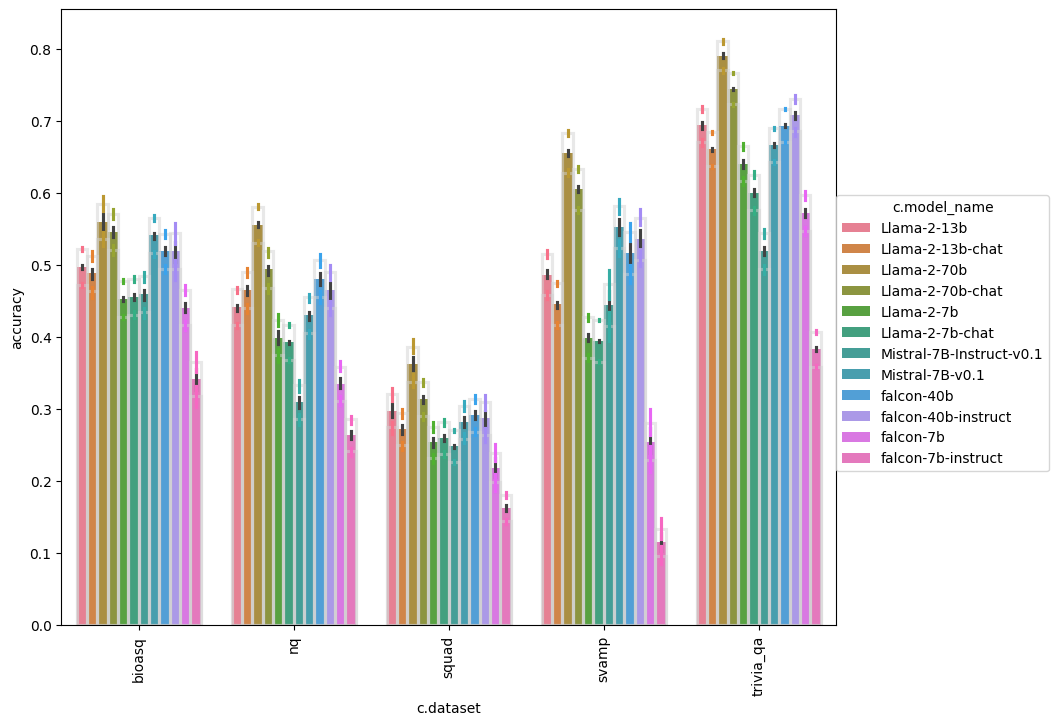

In [28]:
# just select the base entailment_model and metric, and ignore 'max_from' accuracies
acc = 'accuracy'
plot_grouped(perfdf, metric='means', x='c.dataset', hue='c.model_name')
plt.gca().set_ylabel(acc)

Base models generate a little bit more diversity but not much.

In [29]:
from constants import COLORS, TEXTWIDTH, GOLDEN_RATIO, METRIC_NAMES, MODEL_NAMES, PRETTY_NAMES
import matplotlib.patches as mpatches

In [39]:
# Full Figure 2 plot for the paper
# We want a massive grid of plots that include AUROC and AU RA C for each dataset (in rows) and model (in columns)

def full_sentence_plot(df, models_in_order=[], datasets_in_order=[], methods_in_order=[], metrics_in_order=[], ylim=None, save_path=None):
    tdf = df.copy()
    n_datasets = len(datasets_in_order)
    n_models = len(models_in_order)
    fig, axs = plt.subplots(n_datasets, n_models, figsize=(2.6*TEXTWIDTH, 2*TEXTWIDTH), sharex=True, sharey='row')
    for i, dataset in enumerate(datasets_in_order):
        axs[i,0].set_ylim(bottom=1.0, top=0.0)
        
        for j, model in enumerate(models_in_order):
            gdf = tdf[(tdf['c.dataset'] == dataset) & (tdf['c.model_name'] == model) & (tdf['metric'].isin(metrics_in_order)) & (tdf['method'].isin(methods_in_order))].copy()
            
            for original_name, new_name in METRIC_NAMES.items():
                gdf.loc[gdf['metric'] == original_name,'metric'] = new_name
            if len(gdf) == 0:
                print(f"Skipping {dataset} {model}")
                continue
            ax = axs[i,j]
            g = sns.barplot(
                    x="metric",       # x variable name
                    y="means",       # y variable name
                    hue="method",  # group variable name
                    data=gdf,     # dataframe to plot
                    ax=ax,
                    hue_order = methods_in_order,
                    palette = COLORS,
                    legend = False,
                    errorbar= None,
            )

            # Min value
            temp_min = np.nanmin(gdf['means'])
            temp_max = np.nanmax(gdf['means'])
            current_min, current_max = axs[i,0].get_ylim()
            if current_min > temp_min:
                axs[i,0].set_ylim(bottom=temp_min)
            if current_max < temp_max:
                axs[i,0].set_ylim(top=temp_max)


            # Crosshatch the p_ik_ood
            n_bars = len(methods_in_order) * len(metrics_in_order)
            idxs_to_edit = np.arange(n_bars-len(metrics_in_order), n_bars, 1)
            for bar_idx, bar in enumerate(g.patches):
                if bar_idx in idxs_to_edit:
                    bar.set_hatch('//')
                    bar.set_facecolor('white')
                    bar.set_edgecolor(COLORS['p_ik_ood'])
            sns.despine()
            if i == n_datasets - 1:
                ax.set_xlabel(MODEL_NAMES[model])
            if j == 0:
                ax.set_ylabel(PRETTY_NAMES[dataset])

            ax.set_axisbelow(True)
            ax.grid(axis='y', linestyle=':', linewidth=.5)
        if ylim == None:
            current_min, current_max = axs[i,0].get_ylim()
            current_min -= 0.05
            current_max += 0.05
            ax.set_ylim(bottom=max(current_min, 0), top=min(current_max, 1.0))
        else:
            ax.set_ylim(*ylim)
    
    patches = [mpatches.Patch(color=COLORS[method], label=PRETTY_NAMES[method]) for method in methods_in_order]
    for patch in patches:
        if patch.get_label() == "Embedding Regression - OOD":
            original_edgecolor = patch.get_edgecolor()
            patch.set_hatch('//')
            patch.set_facecolor('white')
            patch.set_edgecolor(original_edgecolor)
    axs[0,2].legend(handles=patches, loc='center', bbox_to_anchor=(1.1, 1.16), ncols=3, frameon=False)
    if save_path is not None:
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0.02)
    return True


In [31]:
from constants import MODEL_NAMES

In [32]:
# UPDATE from JANNIK: fix bug with wrong average
all_relevant_runs = all_runs

# UPDATE from JANNIK: add p_ik ood runs
# PLEASE NOTE: pik runs do not have entailment_model and metric and other configs! (because they are only an eval run!)
all_relevant_runs_with_pik = pd.concat([pik_all_runs, all_relevant_runs])


Comment from Jannik 02/12/23: how do you feel about not sharying ylims between rows? such that we can show differences between methods more clearly?


True

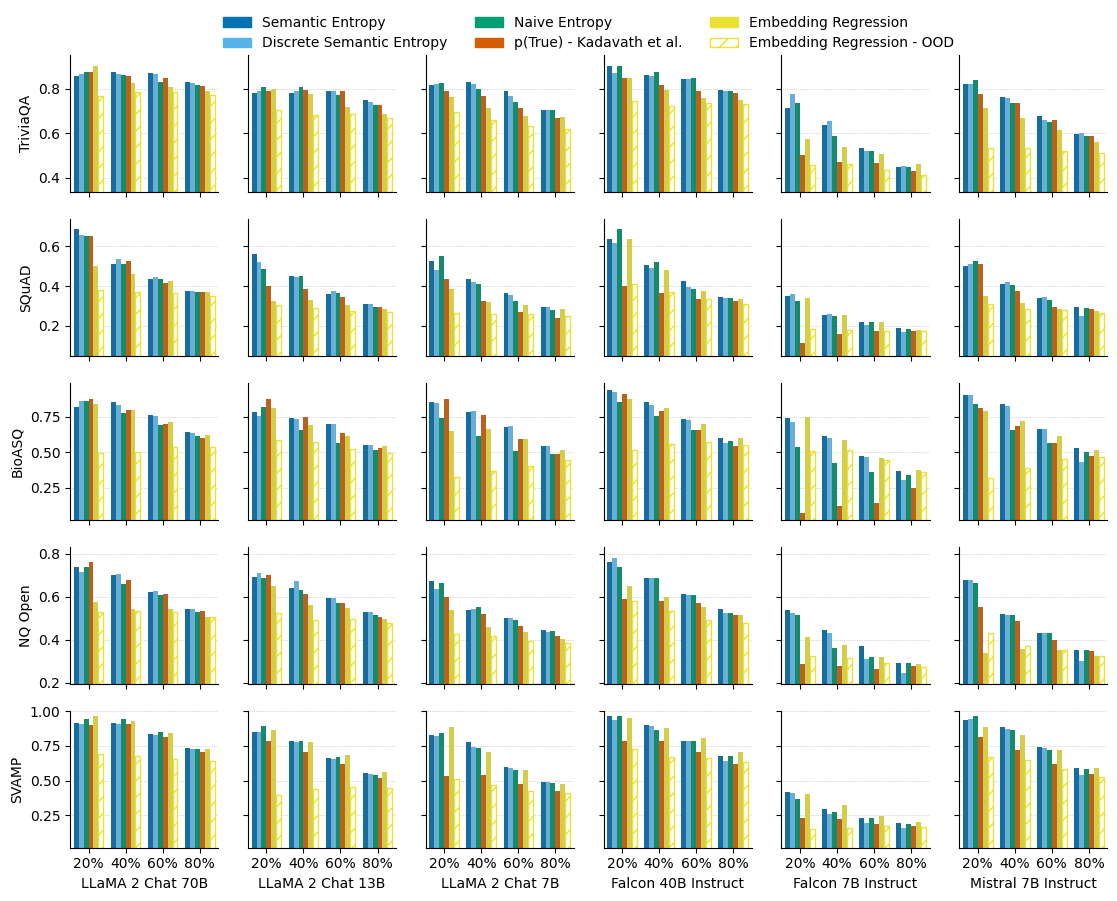

In [40]:
# Backup plot for appendix of all the rejection accuracies

print('Comment from Jannik 02/12/23: how do you feel about not sharying ylims between rows? such that we can show differences between methods more clearly?')

# Plot for Figure 4
full_sentence_plot(all_relevant_runs_with_pik,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'nq', 'svamp'],
                   models_in_order=['Llama-2-70b-chat','Llama-2-13b-chat', 'Llama-2-7b-chat', 'falcon-40b-instruct', 'falcon-7b-instruct', 'Mistral-7B-Instruct-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['accuracy_at_0.2_answer_fraction', 'accuracy_at_0.4_answer_fraction', 'accuracy_at_0.6_answer_fraction', 'accuracy_at_0.8_answer_fraction'],
                   ylim=None,
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_short_rejection_accuracy_fine.pdf")

True

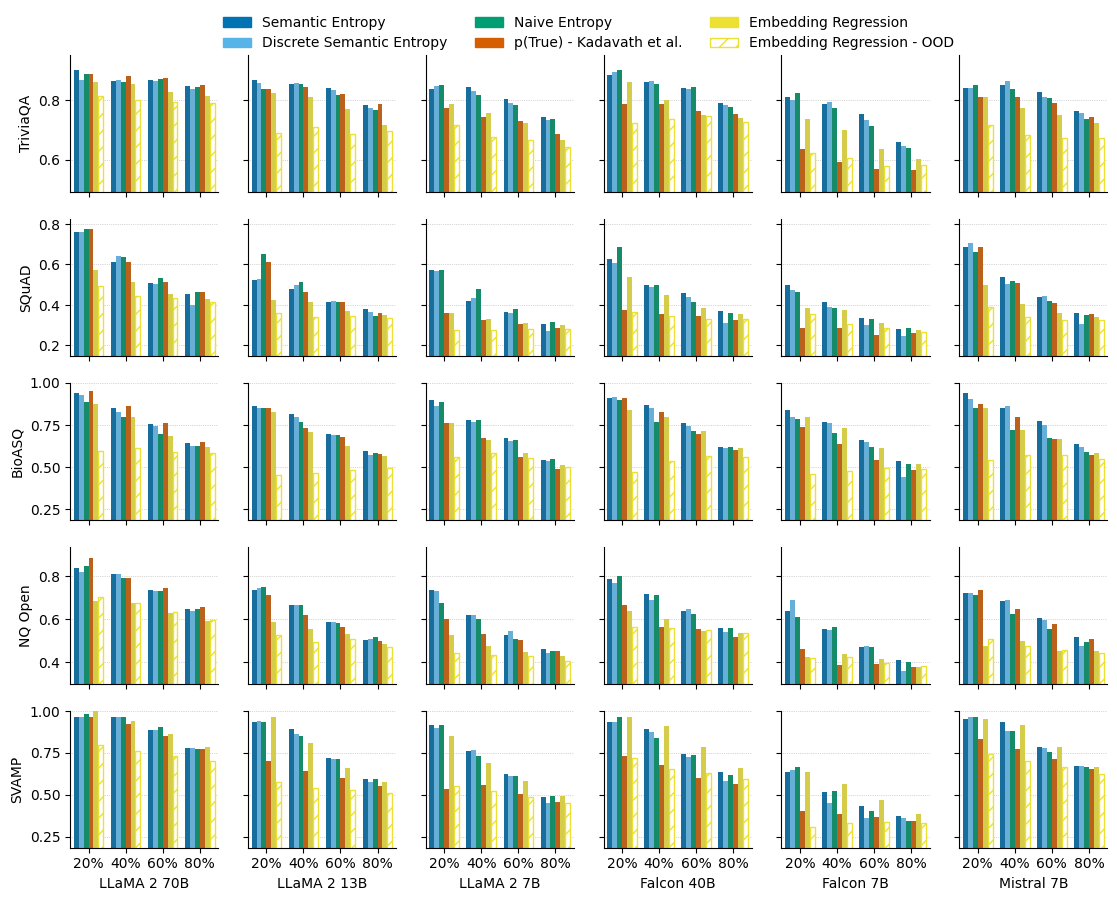

In [41]:
# Backup plot for appendix of all the rejection accuracies

# Plot for Figure 4
full_sentence_plot(all_relevant_runs_with_pik,
                   datasets_in_order=['trivia_qa', 'squad', 'bioasq', 'nq', 'svamp'],
                   models_in_order=['Llama-2-70b', 'Llama-2-13b', 'Llama-2-7b', 'falcon-40b', 'falcon-7b', 'Mistral-7B-v0.1'],
                   methods_in_order = ['semantic_entropy_sum-normalized-rao', 'cluster_assignment_entropy', 'regular_entropy', 'p_false', 'p_ik', 'p_ik_ood'],
                   metrics_in_order=['accuracy_at_0.2_answer_fraction', 'accuracy_at_0.4_answer_fraction', 'accuracy_at_0.6_answer_fraction', 'accuracy_at_0.8_answer_fraction'],
                   save_path="/auto/users/jansen/semantic_uncertainty/notebooks/paper_evals/final_figures/app_short_rejection_accuracy_non_it_fine.pdf")
